<a href="https://colab.research.google.com/github/UKD1211/Deep_Learning_Prac_cX/blob/main/Xavier_glorat_initialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons

In [2]:
X,y = make_moons(n_samples=400,noise=0.3,random_state=42)

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

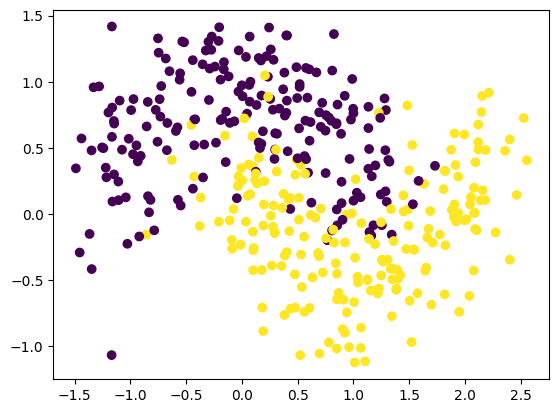

In [4]:
plt.scatter(X[:,0],X[:,1],c = y)

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
model = Sequential()
model.add(Dense(10,activation = 'tanh',input_dim = 2))
model.add(Dense(10,activation = 'tanh'))
model.add(Dense(10,activation = 'tanh'))
model.add(Dense(10,activation = 'tanh'))
model.add(Dense(1,activation = 'sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.get_weights()[0]

array([[-0.34934258, -0.20610261,  0.34130782, -0.36018425, -0.49914867,
         0.69083995,  0.24797165, -0.28760082,  0.2899565 , -0.6161141 ],
       [-0.5168271 ,  0.16692007,  0.5476418 ,  0.3419456 , -0.27327797,
        -0.1707704 ,  0.41456705,  0.29767293, -0.22867513, -0.58365494]],
      dtype=float32)

In [8]:
initial_weights = model.get_weights()

In [9]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [10]:
model.set_weights(initial_weights)

In [12]:
model.get_weights()

[array([[ 0.14108828,  0.15863667,  1.698703  ,  0.77676225, -0.1369314 ,
         -0.23255935,  0.6886222 , -0.5103097 ,  0.08339359,  0.12356245],
        [ 0.05471154, -0.5680178 , -0.324557  , -1.4729972 ,  0.20591865,
         -0.6981744 ,  0.09217536,  0.89414585, -0.89922714,  0.37922978]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.10570787, -0.02521172,  0.03163337, -0.16094075,  0.20692436,
          0.02755669, -0.00675088,  0.42166737,  0.2246334 ,  0.37250298],
        [-0.28066087,  0.04706499,  0.10735887,  0.3438241 ,  0.05992452,
          0.12806867, -0.31231287, -0.23809509, -0.09637996,  0.39021406],
        [ 0.3446658 ,  0.03830299, -0.17295052,  0.46333265, -0.08167385,
         -0.23819903, -0.12403346,  0.11404893, -0.30317768,  0.06760542],
        [ 0.23602541,  0.19905631,  0.05764295,  0.5103991 , -0.16432112,
          0.47293422, -0.2313623 , -0.15935108, -0.02817562,  0.14301254],
        [ 0.18779

In [13]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])


In [15]:
history = model.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.2500 - loss: 0.7357 - val_accuracy: 0.6000 - val_loss: 0.6889
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7281 - loss: 0.6500 - val_accuracy: 0.7000 - val_loss: 0.6290
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8000 - loss: 0.5779 - val_accuracy: 0.7625 - val_loss: 0.5822
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8250 - loss: 0.5214 - val_accuracy: 0.7625 - val_loss: 0.5477
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8406 - loss: 0.4812 - val_accuracy: 0.7625 - val_loss: 0.5237
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8438 - loss: 0.4470 - val_accuracy: 0.7625 - val_loss: 0.5098
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8469 - loss: 0.4244 - val_accuracy: 0.7750 - val_loss: 0.5022
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8406 - loss: 0.4088 - val_accuracy: 0.7750 - 

In [16]:
model.get_weights()

[array([[ 0.23626344,  0.28957075,  1.7096096 ,  0.7235756 , -0.2604365 ,
         -0.4772054 ,  0.84688497, -0.84599864,  0.15406144, -0.03644188],
        [-0.00439815, -0.4600326 , -0.31283602, -1.3777132 ,  0.12801728,
         -0.72609085,  0.2240243 ,  0.7617468 , -0.82194614,  0.15990242]],
       dtype=float32),
 array([-0.10367373,  0.0573464 , -0.28213045,  0.17140004,  0.04684136,
        -0.05642644,  0.26912308,  0.33863854,  0.19510058,  0.013443  ],
       dtype=float32),
 array([[-1.64389491e-01, -3.03524733e-01, -3.89982690e-03,
         -2.86580801e-01,  3.42296183e-01,  2.27882043e-01,
         -2.68325713e-02,  2.53970355e-01,  9.30413231e-02,
          6.08822107e-01],
        [-1.59268990e-01,  2.49691643e-02,  1.10348277e-02,
          4.71689641e-01,  1.89614192e-01,  2.22871810e-01,
         -3.51839006e-01, -3.63982677e-01, -9.59822908e-03,
          4.81522113e-01],
        [ 3.16758096e-01,  1.35407552e-01, -8.37179273e-02,
          3.68721634e-01, -1.84804

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 799us/step


<Axes: >

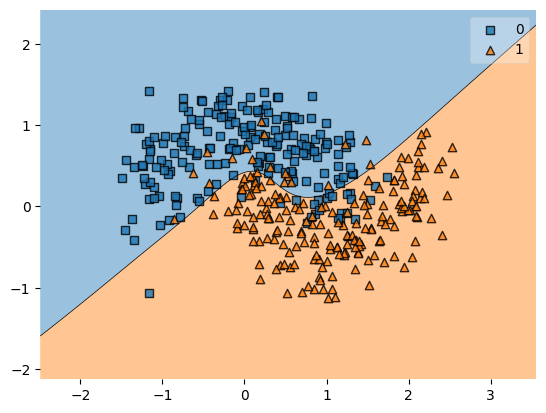

In [17]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X=X, y=y, clf=model)

In [18]:
model2 = Sequential()
model2.add(Dense(10,activation = "relu",input_dim = 2,kernel_initializer = "he_normal"))
model2.add(Dense(10,activation = "relu",kernel_initializer = "he_normal"))
model2.add(Dense(10,activation = "relu",kernel_initializer = "he_normal"))
model2.add(Dense(10,activation = "relu",kernel_initializer = "he_normal"))
model2.add(Dense(1,activation = "sigmoid",kernel_initializer = "he_normal"))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model2.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
history2 = model2.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.1625 - loss: 0.9779 - val_accuracy: 0.2250 - val_loss: 0.8721
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1844 - loss: 0.8733 - val_accuracy: 0.2500 - val_loss: 0.8011
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2313 - loss: 0.7966 - val_accuracy: 0.2875 - val_loss: 0.7489
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2937 - loss: 0.7409 - val_accuracy: 0.3500 - val_loss: 0.7140
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3438 - loss: 0.7053 - val_accuracy: 0.3750 - val_loss: 0.6902
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4875 - loss: 0.6787 - val_accuracy: 0.6125 - val_loss: 0.6728
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7563 - loss: 0.6579 - val_accuracy: 0.8250 - val_loss: 0.6567
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8406 - loss: 0.6410 - val_accuracy: 0.7750 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 839us/step


<Axes: >

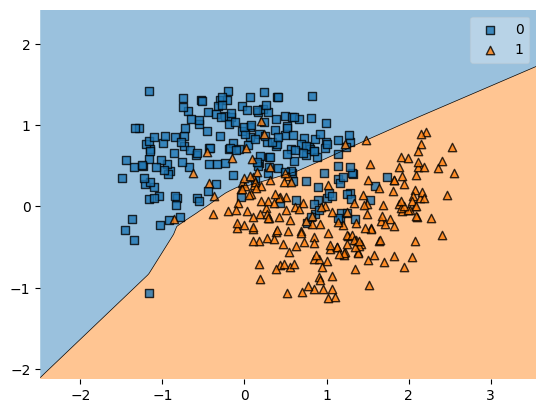

In [20]:
plot_decision_regions(X,y,clf = model2)